In [4]:
# Instalação (rode apenas se não tiver as bibliotecas no seu PC)
# !pip install torch torchvision transformers pillow tqdm scikit-learn matplotlib

import os
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Definir dispositivo (Usa GPU se você tiver uma NVIDIA configurada, senão usa CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Usando dispositivo: {device}')

✅ Usando dispositivo: cpu


In [9]:
# --- AJUSTE OS CAMINHOS ABAIXO ---
# O 'r' antes das aspas evita problemas com as barras do Windows
train_dir = r'C:\Users\paulo\Downloads\Aula 10 - Modelo para Identificar Cats or Dogs-20260406T000954Z-3-001\Aula 10 - Modelo para Identificar Cats or Dogs\dataset_treino'

# Carregar o "cérebro" do modelo (Vision Transformer)
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [10]:
class DogsAndCatsDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.dataset = ImageFolder(root_dir)
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs['pixel_values'].squeeze()
        return pixel_values, label

# Criar o dataset e dividir em 80% treino / 20% validação
full_dataset = DogsAndCatsDataset(train_dir, processor)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoaders (carregam as imagens em lotes de 32)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print(f'Imagens carregadas: {len(full_dataset)}')
print(f'Treino: {len(train_dataset)} | Validação: {len(val_dataset)}')


Imagens carregadas: 1002
Treino: 801 | Validação: 201


In [11]:
num_epochs = 3 
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in tqdm(train_loader, desc=f'Época {epoch+1}/{num_epochs}'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(pixel_values=images, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"✅ Época {epoch+1} finalizada. Média de Loss: {total_loss/len(train_loader):.4f}")

Época 1/3: 100%|███████████████████████████████████████████████████████████████████████| 26/26 [23:14<00:00, 53.63s/it]


✅ Época 1 finalizada. Média de Loss: 0.1440


Época 2/3: 100%|███████████████████████████████████████████████████████████████████████| 26/26 [20:22<00:00, 47.00s/it]


✅ Época 2 finalizada. Média de Loss: 0.0024


Época 3/3: 100%|███████████████████████████████████████████████████████████████████████| 26/26 [20:17<00:00, 46.83s/it]

✅ Época 3 finalizada. Média de Loss: 0.0010


Calculando previsões para a matriz de confusão...


Avaliação: 100%|█████████████████████████████████████████████████████████████████████████| 7/7 [01:39<00:00, 14.25s/it]


<Figure size 800x600 with 0 Axes>

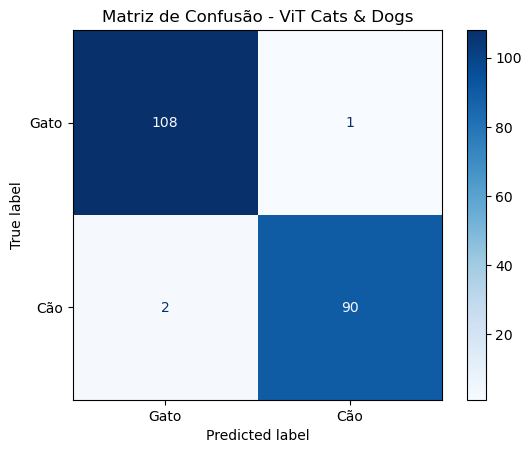

In [13]:
# Gerar a Matriz de Confusão
all_preds, all_labels = [], []
model.eval() # Coloca o modelo em modo de avaliação

print("Calculando previsões para a matriz de confusão...")
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Avaliação'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(pixel_values=images)
        
        _, predicted = outputs.logits.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Criar o gráfico (0: cat, 1: dog)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Gato', 'Cão'])

# Plotar
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão - ViT Cats & Dogs")
plt.show()

🐾 Resultado da Predição: Gato 🐱


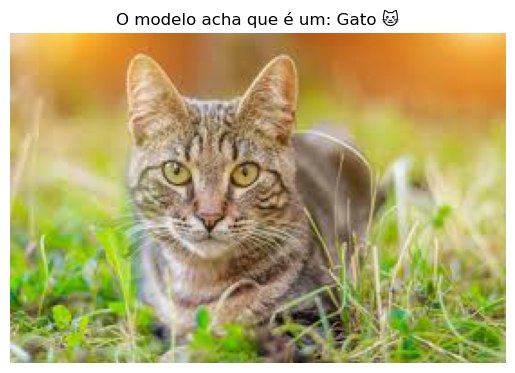

In [12]:
# Ajuste para uma imagem que você queira testar
test_image_path = r'C:\Users\paulo\Downloads\Aula 10 - Modelo para Identificar Cats or Dogs-20260406T000954Z-3-001\Aula 10 - Modelo para Identificar Cats or Dogs\download.jfif'

if os.path.exists(test_image_path):
    image = Image.open(test_image_path)
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_class = torch.argmax(outputs.logits, dim=-1).item()
    
    label = ['Gato 🐱', 'Cachorro 🐶'][predicted_class]
    print(f"🐾 Resultado da Predição: {label}")
    
    plt.imshow(image)
    plt.title(f"O modelo acha que é um: {label}")
    plt.axis('off')
    plt.show()
else:
    print("Arquivo de imagem não encontrado. Verifique o caminho!")